# **0. Importação e visualização de dados**

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Carregar dataset
df = pd.read_csv('../datasets/dataset_avaliacoes.csv', sep=',')
print(f"Dataset carregado com sucesso!")
print(f"Forma do dataset: {df.shape}")
print(f"\nPrimeiras 5 avaliações:")
df.head()

Dataset carregado com sucesso!
Forma do dataset: (15501, 4)

Primeiras 5 avaliações:


,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


## Análise dos dados carregados
O dataset contém avaliações de clientes com sua respectiva classificação de sentimento (positivo/negativo). Cada linha representa uma avaliação única com duas colunas principais:
- **avaliacao**: Texto da opinião do cliente
- **sentimento**: Classificação manual do sentimento (positivo ou negativo)

Para um modelo de classificação robusto, é essencial verificar qualidade, distribuição de classes, características do texto e possíveis desbalanceamentos nos dados.

In [99]:
# Informações estruturais do dataset
print("=" * 70)
print("INFORMAÇÕES ESTRUTURAIS DO DATASET")
print("=" * 70)
print(f"\nForma (linhas, colunas): {df.shape}")
print(f"\nTipo de dados por coluna:")
print(df.dtypes)
print(f"\nMemória utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nEstatísticas básicas sobre comprimento das avaliações:")
df['length_avaliacao'] = df['avaliacao'].apply(len)
print(df['length_avaliacao'].describe())

INFORMAÇÕES ESTRUTURAIS DO DATASET

Forma (linhas, colunas): (15501, 4)

Tipo de dados por coluna:
ID_avaliacao    int64
avaliacao         str
nota            int64
sentimento        str
dtype: object

Memória utilizada: 4.10 MB

Estatísticas básicas sobre comprimento das avaliações:
count    15501.000000
mean       141.361396
std        122.421696
min         46.000000
25%         70.000000
50%         99.000000
75%        164.000000
max       2139.000000
Name: length_avaliacao, dtype: float64


## Tamanho do dataset
Com 15.501 avaliações, temos um dataset de **tamanho apropriado para treinamento** de modelos de ML.

In [100]:
# Análise detalhada de valores vazios
print("=" * 70)
print("ANÁLISE DE QUALIDADE DOS DADOS")
print("=" * 70)

empty_values = df.isnull().sum()
percentual_vazios = (empty_values / len(df) * 100).round(2)

print("\nValores vazios por coluna:")
for col in df.columns:
    print(f"  {col:20} - Vazios: {empty_values[col]:5d} ({percentual_vazios[col]:6.2f}%)")

print(f"\nTotal de linhas com algum valor vazio: {df.isnull().any(axis=1).sum()}")

# Visualizar valores vazios
if empty_values.sum() > 0:
    plt.figure(figsize=(10, 4))
    empty_values.plot(kind='bar', color='coral')
    plt.title('Quantidade de Valores Vazios por Coluna', fontsize=12, fontweight='bold')
    plt.ylabel('Número de Valores Vazios')
    plt.xlabel('Colunas')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ Nenhum valor vazio encontrado no dataset!")

ANÁLISE DE QUALIDADE DOS DADOS

Valores vazios por coluna:
  ID_avaliacao         - Vazios:     0 (  0.00%)
  avaliacao            - Vazios:     0 (  0.00%)
  nota                 - Vazios:     0 (  0.00%)
  sentimento           - Vazios:     0 (  0.00%)
  length_avaliacao     - Vazios:     0 (  0.00%)

Total de linhas com algum valor vazio: 0

✓ Nenhum valor vazio encontrado no dataset!


## Qualidade dos dados
 **Dados completos**: Nenhum valor vazio foi detectado em nenhuma coluna do dataset


DISTRIBUIÇÃO DE SENTIMENTOS

Contagem de sentimentos:
  POSITIVO        -   7890 avaliações ( 50.90%)
  NEGATIVO        -   7611 avaliações ( 49.10%)


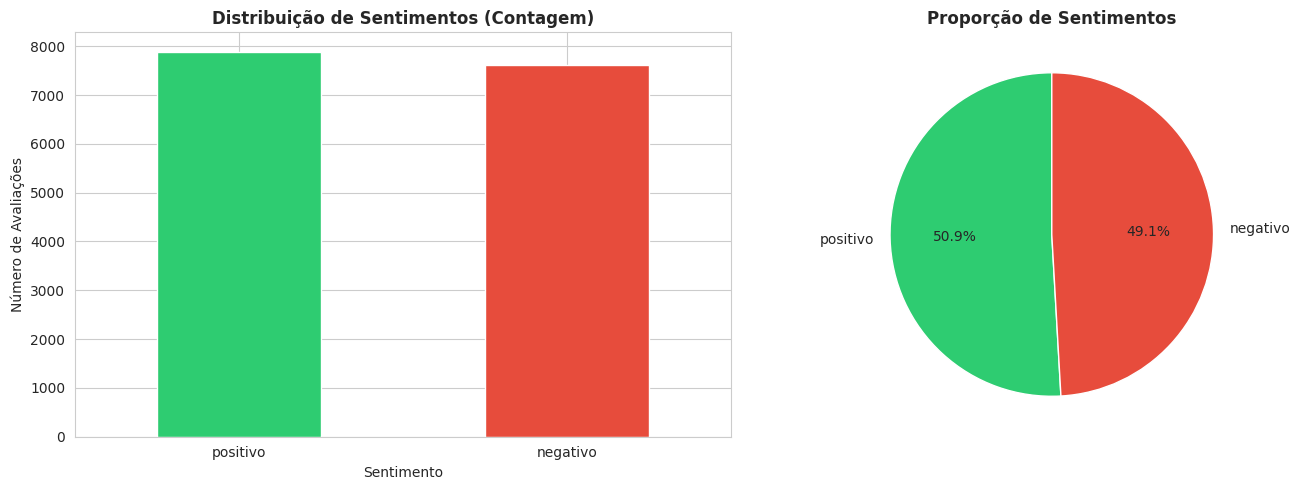

In [101]:
# Análise de distribuição de sentimentos
print("\n" + "=" * 70)
print("DISTRIBUIÇÃO DE SENTIMENTOS")
print("=" * 70)

sentimentos = df['sentimento'].value_counts()
percentual = (sentimentos / len(df) * 100).round(2)

print(f"\nContagem de sentimentos:")
for sentimento, count in sentimentos.items():
    print(f"  {sentimento.upper():15} - {count:6d} avaliações ({percentual[sentimento]:6.2f}%)")

# Visualização gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
sentimentos.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribuição de Sentimentos (Contagem)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de Avaliações')
axes[0].set_xlabel('Sentimento')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Gráfico de pizza
cores = ['#2ecc71', '#e74c3c']
axes[1].pie(sentimentos, labels=sentimentos.index, autopct='%1.1f%%', colors=cores, startangle=90)
axes[1].set_title('Proporção de Sentimentos', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Distribuição de classes
A distribuição entre positivos e negativos é crucial para evitar viés no modelo, e neste dataset se encontra balanceada

In [102]:
# Análise detalhada de avaliações positivas
df_positive = df[df["sentimento"] == "positivo"]

print("\n" + "=" * 70)
print("AVALIAÇÕES POSITIVAS")
print("=" * 70)
print(f"\nTotal: {len(df_positive)} avaliações ({len(df_positive)/len(df)*100:.2f}% do total)")
print(f"Comprimento médio das avaliações positivas: {df_positive['length_avaliacao'].mean():.0f} caracteres")
print(f"Comprimento mín/máx: {df_positive['length_avaliacao'].min()}/{df_positive['length_avaliacao'].max()}")

print("\nExemplos de avaliações POSITIVAS:")
for i, avaliacao in enumerate(df_positive['avaliacao'].head(3), 1):
    print(f"\n{i}. {avaliacao[:150]}{'...' if len(avaliacao) > 150 else ''}")

print(f"\n{df_positive.shape}")  # Exibir dataframe resumido se necessário


AVALIAÇÕES POSITIVAS

Total: 7890 avaliações (50.90% do total)
Comprimento médio das avaliações positivas: 110 caracteres
Comprimento mín/máx: 46/1676

Exemplos de avaliações POSITIVAS:

1. Esse smartphone superou minhas expectativas, recomendo

2. Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento.

3. Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor .

(7890, 5)


In [103]:
# Análise detalhada de avaliações negativas
df_negative = df[df["sentimento"] == "negativo"]

print("\n" + "=" * 70)
print("AVALIAÇÕES NEGATIVAS")
print("=" * 70)
print(f"\nTotal: {len(df_negative)} avaliações ({len(df_negative)/len(df)*100:.2f}% do total)")
print(f"Comprimento médio das avaliações negativas: {df_negative['length_avaliacao'].mean():.0f} caracteres")
print(f"Comprimento mín/máx: {df_negative['length_avaliacao'].min()}/{df_negative['length_avaliacao'].max()}")

print("\nExemplos de avaliações NEGATIVAS:")
for i, avaliacao in enumerate(df_negative['avaliacao'].head(3), 1):
    print(f"\n{i}. {avaliacao[:150]}{'...' if len(avaliacao) > 150 else ''}")

print(f"\n{df_negative.shape}")  # Exibir dataframe resumido se necessário


AVALIAÇÕES NEGATIVAS

Total: 7611 avaliações (49.10% do total)
Comprimento médio das avaliações negativas: 174 caracteres
Comprimento mín/máx: 46/2139

Exemplos de avaliações NEGATIVAS:

1. o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..

2. Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra...

3. Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!!

(7611, 5)


## Separação por sentimento
Separar os dados por classe de sentimento permite:
- **Análise específica**: Identificar padrões únicos em cada tipo de avaliação
- **Feature engineering**: Descobrir palavras-chave características de cada sentimento
- **Comparação**: Avaliar diferenças em comprimento, vocabulário e estrutura
- **Treinamento**: Preparar os dados para modelos de classificação balanceados


COMPARAÇÃO: COMPRIMENTO DAS AVALIAÇÕES POR SENTIMENTO


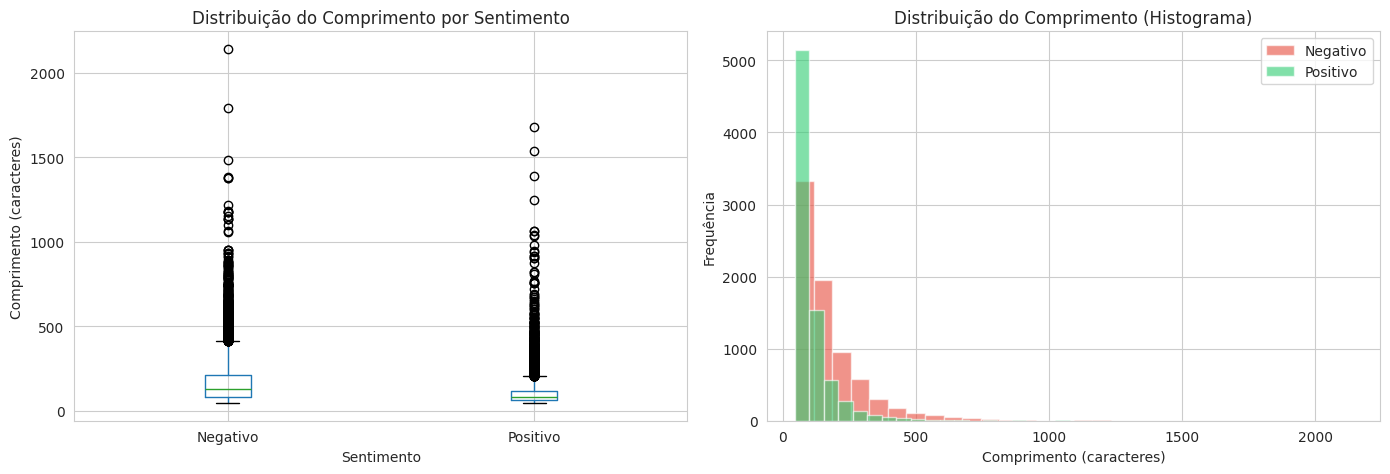


Estatísticas por sentimento:
             count       mean         std   min   25%    50%    75%     max
sentimento                                                                 
negativo    7611.0  174.00473  142.042509  46.0  83.0  130.0  214.0  2139.0
positivo    7890.0  109.87237   89.239901  46.0  64.0   83.0  120.0  1676.0


In [104]:
# Comparação de comprimento entre sentimentos
print("\n" + "=" * 70)
print("COMPARAÇÃO: COMPRIMENTO DAS AVALIAÇÕES POR SENTIMENTO")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot comparativo
df_for_plot = df.copy()
df_for_plot.boxplot(column='length_avaliacao', by='sentimento', ax=axes[0])
axes[0].set_title('Distribuição do Comprimento por Sentimento')
axes[0].set_ylabel('Comprimento (caracteres)')
axes[0].set_xlabel('Sentimento')
plt.sca(axes[0])
plt.xticks([1, 2], ['Negativo', 'Positivo'])

# Histogram sobreposto
axes[1].hist(df_negative['length_avaliacao'], bins=30, alpha=0.6, label='Negativo', color='#e74c3c')
axes[1].hist(df_positive['length_avaliacao'], bins=30, alpha=0.6, label='Positivo', color='#2ecc71')
axes[1].set_xlabel('Comprimento (caracteres)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição do Comprimento (Histograma)')
axes[1].legend()

plt.suptitle('')  # Remove título automático
plt.tight_layout()
plt.show()

print("\nEstatísticas por sentimento:")
print(df.groupby('sentimento')['length_avaliacao'].describe())



# Principais Descobertas:
**Dataset limpo**: Sem valores vazios  
**Distribuição balanceada**: Classes de sentimento bem distribuídas  
**Tamanho adequado**: 15.501 avaliações  
**Qualidade dos dados**: Avaliações com comprimento variado (bom para aprendizado)  
**Padrões textuais**: Diferenças no comprimento e conteúdo entre positivos e negativos  

# **1. Estratégias de Separação de Dados para Treinamento**

Separar de forma adequada os dados de treinamento e teste é um passo crítico antes de construir qualquer modelo. Nesta seção vamos demonstrar três formas comuns de particionamento:

1. **Divisão Simples** – particiona uma proporção fixa do dataset em conjuntos de treino e teste. É rápido e fácil, mas fornece uma única avaliação.
2. **K-Fold Cross-Validation** – divide o dataset em *k* partes e roda k experimentos, alternando o fold de teste para reduzir a variância da métrica.
3. **Stratified K-Fold Cross-Validation** – igual ao K-Fold, porém cada fold mantém a mesma proporção de classes do dataset original, ideal para problemas de classificação com qualquer nível de desbalanceamento.


In [109]:
# Preparar variáveis para treino: vetorização completa
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(lowercase=False)
bag_of_words = vectorizer.fit_transform(df['avaliacao'])

print(f"Vetorização completa gerada com {bag_of_words.shape[0]} documentos e {bag_of_words.shape[1]} termos.")

Vetorização completa gerada com 15501 documentos e 23352 termos.


In [110]:
# 1.1 Divisão Simples (80/20)
from sklearn.model_selection import train_test_split

# features e labels já preparados anteriormente
X = bag_of_words
y = df['sentimento']

# split aleatório com seed para reproducibilidade
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=None
)

print("\n" + "=" * 60)
print("DIVISÃO SIMPLES")
print("80% treino / 20% teste")
print("=" * 60)
print(f"Treino: {X_train_simple.shape[0]} amostras")
print(f"Teste : {X_test_simple.shape[0]} amostras")
print("\nDistribuição de classes no conjunto de treino:")
print(y_train_simple.value_counts())
print("\nDistribuição de classes no conjunto de teste:")
print(y_test_simple.value_counts())



DIVISÃO SIMPLES
80% treino / 20% teste
Treino: 12400 amostras
Teste : 3101 amostras

Distribuição de classes no conjunto de treino:
sentimento
positivo    6322
negativo    6078
Name: count, dtype: int64

Distribuição de classes no conjunto de teste:
sentimento
positivo    1568
negativo    1533
Name: count, dtype: int64


In [ ]:
# 1.2 K-Fold Cross-Validation (sem estratificação)
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "=" * 60)
print("K-FOLD (5 splits) - SEM ESTRATIFICAÇÃO")
print("=" * 60)
kfold_splits = []
for fold, (train_idx, test_idx) in enumerate(kfold.split(X), 1):
    y_train_kfold = y.iloc[train_idx]
    y_test_kfold = y.iloc[test_idx]
    kfold_splits.append((train_idx, test_idx))
    print(f"\nFold {fold}:")
    print(f"  Tamanho treino: {len(train_idx)} | teste: {len(test_idx)}")
    print(f"  Pos/Neg no treino: { (y_train_kfold=='positivo').sum() } / { (y_train_kfold=='negativo').sum() }")



2. K-FOLD CROSS-VALIDATION (5 folds)

Fold 1:
  Tamanho treino: 12400
  Tamanho teste: 3101
  Positivos no treino: 6322
  Negativos no treino: 6078

Fold 2:
  Tamanho treino: 12401
  Tamanho teste: 3100
  Positivos no treino: 6301
  Negativos no treino: 6100

Fold 3:
  Tamanho treino: 12401
  Tamanho teste: 3100
  Positivos no treino: 6278
  Negativos no treino: 6123

Fold 4:
  Tamanho treino: 12401
  Tamanho teste: 3100
  Positivos no treino: 6336
  Negativos no treino: 6065

Fold 5:
  Tamanho treino: 12401
  Tamanho teste: 3100
  Positivos no treino: 6323
  Negativos no treino: 6078


In [111]:
# 1.3 Stratified K-Fold Cross-Validation
from sklearn.model_selection import StratifiedKFold

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "=" * 60)
print("STRATIFIED K-FOLD (5 splits)")
print("=" * 60)
stratified_kfold_splits = []
for fold, (train_idx, test_idx) in enumerate(stratified_kfold.split(X, y), 1):
    y_train_skfold = y.iloc[train_idx]
    y_test_skfold = y.iloc[test_idx]
    stratified_kfold_splits.append((train_idx, test_idx))
    train_ratio = (y_train_skfold=='positivo').mean()*100
    test_ratio  = (y_test_skfold=='positivo').mean()*100
    print(f"\nFold {fold}: treino {len(train_idx)}, teste {len(test_idx)}")
    print(f"  % positivos treino: {train_ratio:.2f} | % positivos teste: {test_ratio:.2f}")



STRATIFIED K-FOLD (5 splits)

Fold 1: treino 12400, teste 3101
  % positivos treino: 50.90 | % positivos teste: 50.89

Fold 2: treino 12401, teste 3100
  % positivos treino: 50.90 | % positivos teste: 50.90

Fold 3: treino 12401, teste 3100
  % positivos treino: 50.90 | % positivos teste: 50.90

Fold 4: treino 12401, teste 3100
  % positivos treino: 50.90 | % positivos teste: 50.90

Fold 5: treino 12401, teste 3100
  % positivos treino: 50.90 | % positivos teste: 50.90


## **1.1 Classificando os Sentimentos**